# **1. Import Libraries and Parameters**

In [1]:
import pandas as pd
import numpy as np
import glob as glob
import math as math
import scipy.stats as stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
#import seaborn.apionly as sns
import matplotlib.patches as mpatches

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

import seaborn as sns
sns.set(color_codes = True)

from matplotlib import gridspec
from matplotlib import colors
from matplotlib import artist
from matplotlib import rc_context

from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import percentileofscore

%matplotlib inline

In [2]:
custom_rcParams = {
    'figure.figsize': (8, 3),
    'font.family': 'Arial',
    'font.size': 10,
    'font.weight': 'regular',
    'axes.labelsize': 14,
    'axes.formatter.useoffset': False,
    'axes.formatter.limits': (-4, 4),
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42
}

mpl.rcParams.update(custom_rcParams)
sns.set_context('paper', rc=custom_rcParams)

import brewer2mpl
brewer2mpl.print_maps()
COLOR_LIST = brewer2mpl.get_map('Set3', 'Qualitative', 12).mpl_colors

Sequential
Blues     :  {3, 4, 5, 6, 7, 8, 9}
BuGn      :  {3, 4, 5, 6, 7, 8, 9}
BuPu      :  {3, 4, 5, 6, 7, 8, 9}
GnBu      :  {3, 4, 5, 6, 7, 8, 9}
Greens    :  {3, 4, 5, 6, 7, 8, 9}
Greys     :  {3, 4, 5, 6, 7, 8, 9}
OrRd      :  {3, 4, 5, 6, 7, 8, 9}
Oranges   :  {3, 4, 5, 6, 7, 8, 9}
PuBu      :  {3, 4, 5, 6, 7, 8, 9}
PuBuGn    :  {3, 4, 5, 6, 7, 8, 9}
PuRd      :  {3, 4, 5, 6, 7, 8, 9}
Purples   :  {3, 4, 5, 6, 7, 8, 9}
RdPu      :  {3, 4, 5, 6, 7, 8, 9}
Reds      :  {3, 4, 5, 6, 7, 8, 9}
YlGn      :  {3, 4, 5, 6, 7, 8, 9}
YlGnBu    :  {3, 4, 5, 6, 7, 8, 9}
YlOrBr    :  {3, 4, 5, 6, 7, 8, 9}
YlOrRd    :  {3, 4, 5, 6, 7, 8, 9}
Diverging
BrBG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PRGn      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PiYG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PuOr      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdBu      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdGy      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlBu    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlGn    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
Spect

In [4]:
GRAY = (0.95, 0.95, 0.95, 1)
LIGHT_BLUE = (0.65098041296005249, 0.80784314870834351, 0.89019608497619629, 1.0)
BLUE = (0.12572087695201239, 0.47323337360924367, 0.707327968232772, 1.0)
LIGHT_GREEN = (0.68899655751153521, 0.8681737867056154, 0.54376011946622071, 1.0)
GREEN = (0.21171857311445125, 0.63326415104024547, 0.1812226118410335, 1.0)
PINK = (0.98320646005518297, 0.5980161709820524, 0.59423301088459368, 1.0)
RED = (0.89059593116535862, 0.10449827132271793, 0.11108035462744099, 1.0)
LIGHT_ORANGE = (0.99175701702342312, 0.74648213716698619, 0.43401768935077328, 1.0)
ORANGE = (0.99990772780250103, 0.50099192647372981, 0.0051211073118098693, 1.0)
LIGHT_PURPLE = (0.78329874347238004, 0.68724338552531095, 0.8336793640080622, 1.0)
PURPLE = (0.42485198495434734, 0.2511495584950722, 0.60386007743723258, 1.0)
YELLOW = (0.99760092286502611, 0.99489427150464516, 0.5965244373854468, 1.0)
LIGHT_BROWN = (0.9, 0.6, 0.5, 1.0)
BROWN = (0.69411766529083252, 0.3490196168422699, 0.15686275064945221, 1.0)

YELLOW = (255/256.,255/256.,51/256.,1.0)
BLUE = (55/256.,126/256.,184/256.,1.0)
PURPLE = (152/256.,78/256.,163/256.,1.0)
RED = (228/256.,26/256.,28/256.,1.0)
GREEN = (77/256.,175/256.,74/256.,1.0)
BROWN = (166/256.,86/256.,40/256.,1.0)
ORANGE = (255/256.,127/256.,0,1.0)
GRAY = (0.95, 0.95, 0.95, 1.0)

MUT_SIG_COLORS = [GRAY, LIGHT_BLUE, PINK, LIGHT_PURPLE, LIGHT_BROWN, LIGHT_GREEN, LIGHT_ORANGE]
PRIMARY_SIG_COLORS = [GRAY, LIGHT_GREEN, YELLOW, LIGHT_PURPLE, LIGHT_BLUE, LIGHT_ORANGE, BLUE, RED]

# DEFINE mutation and CNA types
MULTIPLE_MUTS = 3
SILENT = 0
MISSENSE_MUTATION = 1
TRUNCATED_MUTATION = 2
INFRAME_INDEL = 8

AMP = 6
HIGH_AMP = 7
HOMOZYGOUS_DEL = 5
LOH = 4
HOMOZYGOUS_DEL_AND_AMP = 9

# DEFINE COLORS for visualization
ALT_COLORS = {SILENT: GRAY,
             MISSENSE_MUTATION: LIGHT_GREEN,
             TRUNCATED_MUTATION: GREEN,
             MULTIPLE_MUTS: BROWN,
             LOH: LIGHT_BLUE,
             HOMOZYGOUS_DEL: BLUE,
             AMP: PINK,
             HIGH_AMP: RED,
             HOMOZYGOUS_DEL_AND_AMP:PURPLE,
             INFRAME_INDEL: LIGHT_ORANGE,
              10: "lime",
              11: "green"
            }
RESPONDER_COL = "forestgreen"
NRESPONDER_COL = "goldenrod"
SD_COL = "cornflowerblue"
CR_COL = GREEN
PR_COL = LIGHT_GREEN
PD_COL = "goldenrod"
MR_COL = PURPLE
LN_COL = PURPLE

In [5]:
# more color settings
RCOLORS = {
    'wheat3':'#CDBA96',
    'gold':"#FFD700",
    'coral1':'#FF7256',
    'dodgerblue3':'#1874CD',
    'skyblue':"#87CEEB",
    'skyblue3':"#6CA6CD",
    'orchid4':"#8B4789",
    'plum1':"#FFBBFF",
    'indianred1':"#FF6A6A",
    'firebrick1':"#FF3030",
    'firebrick4':"#8B1A1A",
    'hotpink2':"#EE6AA7",
    'firebrick':"#B22222",
    'grey90':"#E5E5E5",
    'magenta4':"#8B008B",
    'aquamarine2':"#76EEC6",
    'gray50':"#7F7F7F",
    'gray20':"#333333",
    'darkorchid4':"#68228B",
    'dodgerblue2':"#1C86EE",
    'palevioletred3':"#CD6889",
    'skyblue4':"#4A708B",
    'cyan3':"#00CDCD",
    'salmon3':"#CD7054",
    'seagreen3':"#43CD80",  
    'skyblue2':"#7EC0EE", 
    'skyblue1':"#87CEFF", 
    'seagreen2':"#4EEE94",
    'royalblue3':"#3A5FCD",
    'brown3':"#CD3333",
    'seagreen3':"#43CD80",
    'palegreen3':"#7CCD7C",
    'darkslategray3':"#79CDCD",
    'darkcyan':"#008B8B",
    'darkblue':"#00008B",
    'palevioletred3':"#CD6889",
    'peachpuff':"#FFDAB9",
    'palegreen3':"#7CCD7C",
    'slateblue1':"#836FFF",
    'tomato':"#FF6347",
    'palevioletred':"#DB7093",
    'lemonchiffon4': "#8B8970",
    'indianred':"#CD5C5C",
    'lemonchiffon2':"#EEE9BF",
    'slateblue3':"#6959CD",
    'sandybrown':"#F4A460",
    'palegreen2':"#90EE90",
    'turquoise3':"#00C5CD",
    'thistle':"#D8BFD8",
    'antiquewhite2':"#EEDFCC",
    'cadetblue':"#5F9EA0",
    'salmon4':"#8B4C39",
    'cadetblue2':"#8EE5EE",
    'rosybrown':"#BC8F8F",
    'gray80':"#CCCCCC",
    'darkseagreen':"#8FBC8F"        
}

COLOR_MAP = {
    'Cosmic 1+5':'antiquewhite2',
    'UV': 'gold',
    'Alkylating': 'coral1',
    'Clonal Mut': 'indigo',
    'Subclonal Mut': 'plum',
    'Genome Doubled': 'darkcyan'
}
# generate colors
def Colormap(feature):
    if feature not in COLOR_MAP:
        raise ValueError(feature + ' not found in COLOR_MAP')
    if COLOR_MAP[feature] not in RCOLORS:
        return COLOR_MAP[feature] 
#        raise ValueError(COLOR_MAP[feature] + ' not found in hexadecimal color conversion')
    return RCOLORS[COLOR_MAP[feature]]

# set default params
custom_rcParams = {
    'figure.figsize': (8, 3),
    # 'font.family': 'Arial',
    'font.size': 14,
    'font.weight': 'regular',
    'axes.labelsize': 14,
    'axes.formatter.useoffset': False,
    'axes.formatter.limits': (-4, 4),
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42
}

mpl.rcParams.update(custom_rcParams)
sns.set_context('paper', rc=custom_rcParams)
sns.set_style("white", {"grid.linestyle": u'--', "axes.grid": True, "grid.color":"0.9"})

# **2. Inspect Data**

In [3]:
# clinical data
import pandas as pd
suppTables = "PublicationData/Supplementary_Tables.xlsx"
suppData = "PublicationData/Supplementary_Data.xlsx"

clinicalSheet = "Supplemental Table 1"

clinicalDF = pd.read_excel(suppTables, sheet_name = clinicalSheet, index_col=0, header=2).iloc[0:144]
clinicalDF[0:5]

,total_muts,nonsyn_muts,clonal_muts,subclonal_muts,heterogeneity,total_neoantigens,CNA_prop,"gender (Male=1, Female=0)",biopsy site,monthsBiopsyPreTx,...,postCTLA4,postMAPKTx,postCombinedCTLA_PD1,numPriorTherapies,biopsy site_categ,biopsyContext (1=Pre-Ipi; 2=On-Ipi; 3=Pre-PD1; 4=On-PD1),daysBiopsyToPD1,daysBiopsyAfterIpiStart,purity,ploidy
Patient1,34.0,22.0,12.0,10.0,0.454545,49.0,0.321417,0.0,skin,2.8,...,0.0,0.0,0.0,1.0,skin,3.0,-84.0,na,0.92,1.73
Patient10,96.0,71.0,48.0,22.0,0.314286,230.0,0.391384,0.0,skin,0.4,...,1.0,1.0,0.0,2.0,skin,3.0,-12.0,107,0.83,1.84
Patient100,200.0,126.0,98.0,24.0,0.196721,301.0,0.029447,0.0,skin,3.1,...,0.0,0.0,0.0,1.0,skin,3.0,-94.0,33,0.11,2.17
Patient102,370.0,246.0,215.0,26.0,0.107884,825.0,0.169389,1.0,brain,2.1,...,0.0,0.0,0.0,0.0,brain,3.0,-64.0,na,0.70,3.24
Patient104,130.0,96.0,65.0,28.0,0.301075,329.0,0.206518,0.0,lymph node,1.9,...,0.0,0.0,0.0,0.0,lymph node,3.0,-57.0,na,0.86,4.58


In [7]:
# mutational signature data
mutsigSheet = "Mutational Sig Activity"

mutsigDF = pd.read_excel(suppData, sheet_name = mutsigSheet, header=3, index_col=0)
print(mutsigDF[0:5])

mutsigDF.columns = ['UV', 'Alkylating', 'Cosmic 1+5']

                     UV    Alkylating  Cosmic 1+5 (Aging+ Signature)
Patient                                                             
Patient145   370.425028  4.268520e+00                      42.307208
Patient125    38.074134  1.037356e+01                      36.549862
Patient100   134.899883  1.269846e+01                      33.400423
Patient62   8941.997050  1.320000e-09                     354.071545
Patient204  2168.898181  9.107963e+01                     292.022232


In [8]:
# merge in clinical and DNA data 
tumorDF = clinicalDF.merge(mutsigDF, left_index=True, right_index=True)
tumorDF[0:5]

,total_muts,nonsyn_muts,clonal_muts,subclonal_muts,heterogeneity,total_neoantigens,CNA_prop,"gender (Male=1, Female=0)",biopsy site,monthsBiopsyPreTx,...,numPriorTherapies,biopsy site_categ,biopsyContext (1=Pre-Ipi; 2=On-Ipi; 3=Pre-PD1; 4=On-PD1),daysBiopsyToPD1,daysBiopsyAfterIpiStart,purity,ploidy,UV,Alkylating,Cosmic 1+5
Patient1,34.0,22.0,12.0,10.0,0.454545,49.0,0.321417,0.0,skin,2.8,...,1.0,skin,3.0,-84.0,na,0.92,1.73,0.509426,2.514556,28.973872
Patient10,96.0,71.0,48.0,22.0,0.314286,230.0,0.391384,0.0,skin,0.4,...,2.0,skin,3.0,-12.0,107,0.83,1.84,35.883346,6.810735,42.303101
Patient100,200.0,126.0,98.0,24.0,0.196721,301.0,0.029447,0.0,skin,3.1,...,1.0,skin,3.0,-94.0,33,0.11,2.17,134.899883,12.698465,33.400423
Patient102,370.0,246.0,215.0,26.0,0.107884,825.0,0.169389,1.0,brain,2.1,...,0.0,brain,3.0,-64.0,na,0.70,3.24,281.460930,24.053939,42.484586
Patient104,130.0,96.0,65.0,28.0,0.301075,329.0,0.206518,0.0,lymph node,1.9,...,0.0,lymph node,3.0,-57.0,na,0.86,4.58,15.669807,3.587685,87.736229


In [9]:
# read in CNA matrix by patient -- for convenience, this has been preprocessed

cnaSheet = "Gene CNAs"

cnaDF = pd.read_excel(suppData,sheet_name = cnaSheet, header=4,index_col=0)

def CNAType(cna):
    translateDict = {"HDEL":HOMOZYGOUS_DEL, 
                     "AMP":AMP,
                     "HIGH_AMP":HIGH_AMP,
                     "LOH":LOH,
                     "HDEL_AMP":HOMOZYGOUS_DEL_AND_AMP
                     }
    if cna in translateDict:
        return translateDict[cna]
    else:
        try:
            out = int(float(cna))
            return out
        except: # not a numeric type
            return cna
    
def CNAType_Series(cnaSeries):
    return(cnaSeries.apply(CNAType))

cnaDF = cnaDF.apply(CNAType_Series)[tumorDF.index] # limit to the 144 tumors in our cohort

cnaDF[0:5]

,Patient1,Patient10,Patient100,Patient102,Patient104,Patient105,Patient106,Patient107,Patient108,Patient11,...,Patient83,Patient84,Patient86,Patient87,Patient88,Patient9,Patient94,Patient96,Patient98,Patient99
Gene,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,4,4,0,0,4
7SK,0,4,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0
A1BG,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,4,0,0,4
A1BG-AS1,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,4,0,0,4
A1CF,4,4,0,4,4,4,4,4,0,4,...,0,0,0,0,4,0,4,4,4,0


## **3. Inspect Transcriptomics Data**

## **3.1. Gene Expression Data**

In [5]:
# read in RNA data
allRNAFile = "OriginalData/GeneExpression.txt"
allRNADF = pd.read_csv(allRNAFile, sep="\t", low_memory=False,index_col=0)

In [19]:
allRNADF.to_csv("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/Data/Data_Melanoma/OriginalData/GeneExpression.csv", index = True)

In [10]:
nanostringFile = 'OriginalData/addData/nanostring_genes.txt'
nanostringGenes = list(pd.read_csv(nanostringFile,sep="\t",low_memory=False, header=None)[0])

In [11]:
mangusoGeneFile = 'OriginalData/addData/manguso_genes.txt'
mangusoGenes = list(pd.read_csv(mangusoGeneFile,sep="\t",low_memory=False, header=None)[0])

## **3.2 single sample GSEA**

In [37]:
suppData = "OriginalData/addData/updated_ssGSEA_SuppData.txt"

#ssGSEASheet = "ssGSEA geneset scores"

#ssGSEADF = pd.read_excel(suppData, sheet_name = ssGSEASheet, header=5, index_col=0).iloc[0:144]
ssGSEADF = pd.read_csv(suppData, sep="\t", low_memory=False, index_col=0)
paper_orders = ssGSEADF.columns.tolist()

In [13]:
import gseapy as gp

def load_gmt_as_dict(gmt_file):
    gene_sets = {}
    with open(gmt_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            set_name = parts[0]
            # parts[1] is description (often ignored)
            # Upper-case genes and remove any empty strings / duplicates
            genes = [g.strip().upper() for g in parts[2:] if g.strip()]
            # preserve order but remove duplicates
            seen = set()
            genes_unique = []
            for g in genes:
                if g not in seen:
                    seen.add(g)
                    genes_unique.append(g)
            gene_sets[set_name] = genes_unique
    return gene_sets

mhc_ii = [
    "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5"
]
mhc_i = ["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "TAP1", "TAP2", "B2M"]

hallmarks_gmt = "OriginalData/h.all.v2025.1.Hs.symbols.gmt"
gmt_dict = load_gmt_as_dict(hallmarks_gmt)  # returns dict with upper-cased genes

# add custom sets as upper-cased lists
gmt_dict["MHC-II"] = [g.upper() for g in mhc_ii]
gmt_dict["MHC-I"] = [g.upper() for g in mhc_i]
ssgsea_res = gp.ssgsea(
    data=allRNADF.T,
    gene_sets=gmt_dict,
    sample_norm_method='rank',
    outdir=None,
    permutation_num=0,
    no_plot=True,
    min_size=1,
    max_size=10000
)
res2d = ssgsea_res.res2d

res_wide = res2d.pivot(index="Name", columns="Term", values="ES")

## **4. Process Data**

In [10]:
# generate amplified tumors for HLA MHC-I genes and TAP2
ampTumors= {}

ampGenes = ['HLA-A', 'HLA-B', 'HLA-C', 'TAP2']

for gene in ampGenes:
    tmp = cnaDF.loc[gene].isin([AMP, HIGH_AMP])
    ampTumors[gene] = list(tmp[tmp].index)

# add additional amp genes
ampTumors['MHC-I HLA'] = set(ampTumors['HLA-A']).intersection(\
                     set(ampTumors['HLA-B']).intersection(\
                     set(ampTumors['HLA-C'])))
ampTumors['MHC-I HLA']

# Create the new columns and initialize to 0
tumorDF['MHC-I amp'] = 0
tumorDF['TAP2 amp'] = 0

# --- Fix is here: Convert the set to a list using list() ---
# Use the list of tumors to set the 'MHC-I amp' value to 1
tumorDF.loc[list(ampTumors['MHC-I HLA']), 'MHC-I amp'] = 1

# Use the list of tumors to set the 'TAP2 amp' value to 1
tumorDF.loc[list(ampTumors['TAP2']), 'TAP2 amp'] = 1

In [11]:

# 3. Làm sạch cơ bản: Loại bỏ khoảng trắng và chuyển về chữ thường
# Dùng .astype(str) để xử lý giá trị None/NaN nếu có
tumorDF['IOTherapy'] = (
    tumorDF['IOTherapy']
    .astype(str)
    .str.strip()
    .str.lower()
)

# 4. Định nghĩa và áp dụng bản đồ chuẩn hóa
standardization_map = {
    # Pembrolizumab
    'pembro': 'Pembrolizumab',
    'pembrolizumab': 'Pembrolizumab',
    'mk3475': 'Pembrolizumab',
    'mk 3475': 'Pembrolizumab',

    # Nivolumab
    'nivo': 'Nivolumab',
    'nivolumab': 'Nivolumab'
}

tumorDF['IOTherapy'] = tumorDF['IOTherapy'].replace(standardization_map)

In [26]:
Ipicols = "daysBiopsyAfterIpiStart"
ipiTreated = pd.to_numeric(tumorDF['daysBiopsyAfterIpiStart'], errors = 'coerce')
postIpi = list(ipiTreated.loc[ipiTreated>0].index)
preIpi = list(ipiTreated.loc[ipiTreated<=0].index)
noIpi = list(tumorDF.loc[tumorDF[Ipicols]=='na'].index)

tumorDF.loc[postIpi, Ipicols]="postIpi"
tumorDF.loc[preIpi, Ipicols]="preIpi"
tumorDF.loc[noIpi, Ipicols]="noIpi"

In [30]:
tumorDF = tumorDF.drop(columns = ["biopsy site"])

In [31]:
tumorDF = tumorDF.rename(columns = {"gender (Male=1, Female=0)": "gender",
                                'Mstage (IIIC=0, M1a=1, M1b=2, M1c=3)': "Mstage",
                                'biopsy site_categ':  'biopsy_site_categ',
                                'biopsyContext (1=Pre-Ipi; 2=On-Ipi; 3=Pre-PD1; 4=On-PD1)':"biopsyContext",
                                'Cosmic 1+5': "Cosmic",
                                'MHC-I amp': "MHCI_Amp",
                                "TAP2 amp": "TAP2_Amp"
})

In [34]:
tumorDF.to_csv("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/Data/Data_Melanoma/OriginalData/clinical_data.csv", index = True)

# **2. Analysis Transcriptomics**

In [6]:
fullDF = pd.read_csv("integrationpipeline_melanoma/integrated_data_melanoma.csv", index_col = 0)

In [16]:
# fullDF = pd.read_csv("synthesizers/gaussiancopula_42/synthetic_data_gaussiancopula_42.csv")

In [7]:
# generate subset of RNAseq features
nanostringFile = 'OriginalData/addData/nanostring_genes.txt'
nanostringGenes = list(pd.read_csv(nanostringFile,sep="\t",low_memory=False, header=None)[0])
mangusoGeneFile = 'OriginalData/addData/manguso_genes.txt'
mangusoGenes = list(pd.read_csv(mangusoGeneFile,sep="\t",low_memory=False, header=None)[0])

genes = ['PRF1', 'GZMA', 'CD8A', 'IFNG', 'HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'CD274', 'PDCD1LG2',
         'PDCD1', 'CDKN2A', 'CDKN2B', 'FOXP3', 'TGFB1', 'ARG1', 'IDO1', 'IL12A', 
         'NOS2', 'JAK1', 'JAK2', 'STAT1', 'STAT2', 'STAT3', 'CXCL9', 'CXCL10', 'CXCR3', 'VEGFA', 'CSF3',
         'IL1A', 'IL1B', 'IL6', 'IL17A', 'CXCL1', 'IL2', 'LDHA']
TRegs = ['CD4', 'FOXP3', 'CTLA4', 'ICOS', 'TNFRSF18']
exhausted = ['TCF7']
activated = ['IL2RA', 'GZMK']
ifna = ['IFNA1', 'IFNA2', 'IFNA4', 'IFNA4', 'IFNA5', 'IFNA6', 'IFNA7', 'IFNA8', 'IFNA10', 'IFNA13', 'IFNA14',
      'IFNA16', 'IFNA17', 'IFNA21', 'IRF9', 'MX1', 'OAS3', 'SYK', 'PTK2B', 'USP18', 'PTPN11', 'TYK2',
       'IRF1', 'SOCS1', 'SOCS3', 'SIN3A']
ifn_inhibit = ['IL1A', 'IL1B', 'CSNK2A1', 'CSNK2A2']
ifng = ['IFNGR1', 'IFNAR1', 'IL15', 'IFNAR2', 'IFNGR2']
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5']
chkpt = ['LAG3', 'HAVCR2', 'TNFRSF18', 'TNFRSF4', 'CTLA4', 'RGMB']
nk = ['TIGIT', 'KLRD1', 'NCAM1']
gamma_delta = ['TRDC']
cytokines = ['TNF', 'IFNB1']
glycolysis = ['PKM', 'GAPDH','CD44','ERO1B','GALE','GNE','NSDHL']
nad = ['NAMPT','NADK']
ppp = ['SHPK']
hypoxia = ['HIF1A']
faOxidation = ['IL4', 'STAT6', 'PPARGC1B', 'CPT1A']
aa = ['SLC1A5', 'NOS2', 'ARG1', 'IDO1']
apc = ['TAP1', 'TAP2', 'IFNAR1', 'NLRC5']
mapk = ['DUSP6', 'NF1', 'SPRED1', 'SPOP','RASA2']
nfkb = ['RELA', 'IKBKB', 'RNF31', 'OTULIN','SHARPIN', 'CFLAR']
mtorc1 = ['RRAGA','RRAGC','LAMTOR1']
pbaf = ['ARID2','PBRM1','BRD7']
wntDownstream = ['EFNB3','APC2','TCF7','MYC', 'TCF12', 'VEGFA']
melanoma = ['MITF', 'AXL']
EMT = ['CDH1', 'VIM', 'FN1', 'CDH2']
nerveGrowthFactor = ['NGFR']
melanoma_antigen = ['MAGEA1', 'MAGEA2B', 'MAGEA3', 'MAGEA4', 'MAGEA5', 'MAGEA6', 'MAGEA7P',
                   'MAGEA8', 'MAGEA9', 'MAGEA10', 'MAGEA11', 'MAGEA12']
otherGenes = ['TRIM22', 'TRIM38', 'IL32','SPATS2L','EPHA3','HERC3','ADAM19','SERPINB9',
         'IFI44L','F3','BEND6','AIG1','MSRB2','TNFRSF9','ANTXR1', 'TP53', 'PTPN14', 'PTPN7', 'SERPINA5', 'AXIN1']
erv = ['ERV3-1', 'DDX58', 'DHX58','IFIH1']
ldha = ['MYC', 'FOXM1', 'KLF4', 'ERBB2', 'HSF1', 'FGFR1', 'SIRT2']
angiogenesis = ['RASIP1', 'ARHGAP29', 'RHOA', 'ROCK1', 'CDC42', 'RAC1']

genes = list(set(genes + TRegs + exhausted + ifn_inhibit + ifna + ifng + mhc2 + mhc1
            + chkpt + nk + gamma_delta + activated + cytokines + glycolysis
            + ppp + hypoxia + faOxidation + aa + apc + erv + ldha + nad + mapk + nfkb + mtorc1 + pbaf
                + wntDownstream + melanoma + EMT + angiogenesis + nerveGrowthFactor+ mangusoGenes
                + melanoma_antigen + nanostringGenes))

genes = [x for x in genes if x in allRNADF.columns]

rnaDF = allRNADF[genes]

print(len(genes))

863


In [9]:
# generate response groups

responderCrit = fullDF['BR'].isin(['CR','PR'])
progressorCrit = fullDF['BR'].isin(['PD'])

responders = fullDF[responderCrit].index
progressors = fullDF[progressorCrit].index
nonresponders = fullDF[~responderCrit].index
nonprogressors = fullDF[~progressorCrit].index
print(len(responders),"responders")
print(len(progressors),"progressors")

fullDF.loc[responders,"PD vs Responder"] = 'Responder'
fullDF.loc[progressors,"PD vs Responder"] = 'Progressor'

fullDF.loc[responders,"Responder"] = 1
fullDF.loc[progressors,"Responder"] = 0

fullDF["PD vs nonPD"] = 'nonPD'
fullDF.loc[progressors,"PD vs nonPD"] = 'PD'

comparisonGroups = [
    'PD vs Responder',
    'PD vs nonPD',
]

fullDF['Responder'].value_counts()

47 responders
56 progressors


Responder
0.0    56
1.0    47
Name: count, dtype: int64

In [10]:
# generate additional columns
fullDF['log nonsyn mutload'] = [math.log(x,10) for x in fullDF['nonsyn_muts']]
fullDF['log clonal mutload'] = [math.log(x,10) for x in fullDF['clonal_muts']]
fullDF['log subclonal mutload'] = [math.log(x,10) for x in fullDF['subclonal_muts']]
fullDF['log neoantigens'] = [math.log(x,10) for x in fullDF['total_neoantigens']]

# add additional category
fullDF.loc[fullDF.index, 'Primary_Type_Categ'] = "Skin or Occult"
mucosalCrit = fullDF['Primary_Type'] == "mucosal"
acralCrit = fullDF['Primary_Type'] == "acral"
fullDF.loc[mucosalCrit | acralCrit, 'Primary_Type_Categ'] = "Mucosal or Acral"

# add dominant mutational signature
uvDom = (fullDF['UV'] > fullDF['Alkylating']) & (fullDF['UV'] > fullDF['Cosmic'])
alkDom = (fullDF['Alkylating'] > fullDF['UV']) & (fullDF['Alkylating'] > fullDF['Cosmic'])
otherDom = (fullDF['Cosmic'] > fullDF['Alkylating']) & (fullDF['Cosmic'] > fullDF['UV'])

print(sum(uvDom), "tumors with dominant UV signature")
print(sum(alkDom), "tumors with dominant alkylating signature")
print(sum(otherDom), "tumors with dominant other (aging + others) signature")

# add to tumorDF
fullDF.loc[uvDom,"Dominant MutSig"] = 'UV'
fullDF.loc[alkDom,"Dominant MutSig"] = 'Alkylating'
fullDF.loc[otherDom,'Dominant MutSig'] = 'Other'

85 tumors with dominant UV signature
3 tumors with dominant alkylating signature
33 tumors with dominant other (aging + others) signature


In [11]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
style = "mac"
def TestMedian(v1, v2, VERBOSE = False, style = style):
    test1 = [float(x) for x in v1 if not np.isnan(x)]
    test2 = [float(x) for x in v2 if not np.isnan(x)]
    if len(v1) != len(test1) or len(v2) != len(test2): # nulls found
        if VERBOSE:
            print("WARNING: NULL values found in comparison groups and ignored")
        
    if style == "pc":
        (stat, pvalue) = mannwhitneyu(test1,test2, alternative = "two-sided")
    else: #  style = "mac"
        pvalue = mannwhitneyu(test1, test2)[1] * 2 # multiply by 2 to get two-sided p-value
    (meanstat, meanpvalue) = ttest_ind(test1, test2, equal_var = False)
    if VERBOSE:
        print("Group 1: median =", str(np.median(test1)), "mean = ", str(np.mean(test1)))
        print("Group 2: median =", str(np.median(test2)), "mean = ", str(np.mean(test2)))
        print("Mann Whitney rank test p-value is", pvalue, "T-test p-value = ", meanpvalue)
    diffMedian = np.median(test1) - np.median(test2)
    

    if diffMedian == 0:
        normDiffMedian = 0
    else:
        if np.median(test1 + test2) == 0:
            normalization = ((np.median(test1) + np.median(test2))/2.0)
        else:
            normalization = np.median(test1 +test2)
            
        normDiffMedian = diffMedian/normalization
        
    return pvalue, meanpvalue, normDiffMedian

In [30]:
responders_df = fullDF[fullDF["PD vs Responder"]=="Responder"]
progressor_df = fullDF[fullDF["PD vs Responder"]=="Progressor"]
pvalues = []
normDiffMedians = []
for gene in genes:
    group1 = responders_df[gene].values
    group2 = progressor_df[gene].values
    pvalue, meanpvalue, normDiffMedian = TestMedian(group1, 
                            group2, 
                            VERBOSE=False, style = "pc")
    pvalues.append(pvalue)
    normDiffMedians.append(normDiffMedian)    
degs_results = {"Gene":genes, "Pvalue": pvalues, "DiffMedian": normDiffMedians}
degs_df = pd.DataFrame(degs_results).set_index("Gene")

Text(0.5, 0, 'difference in medians (normalized)')

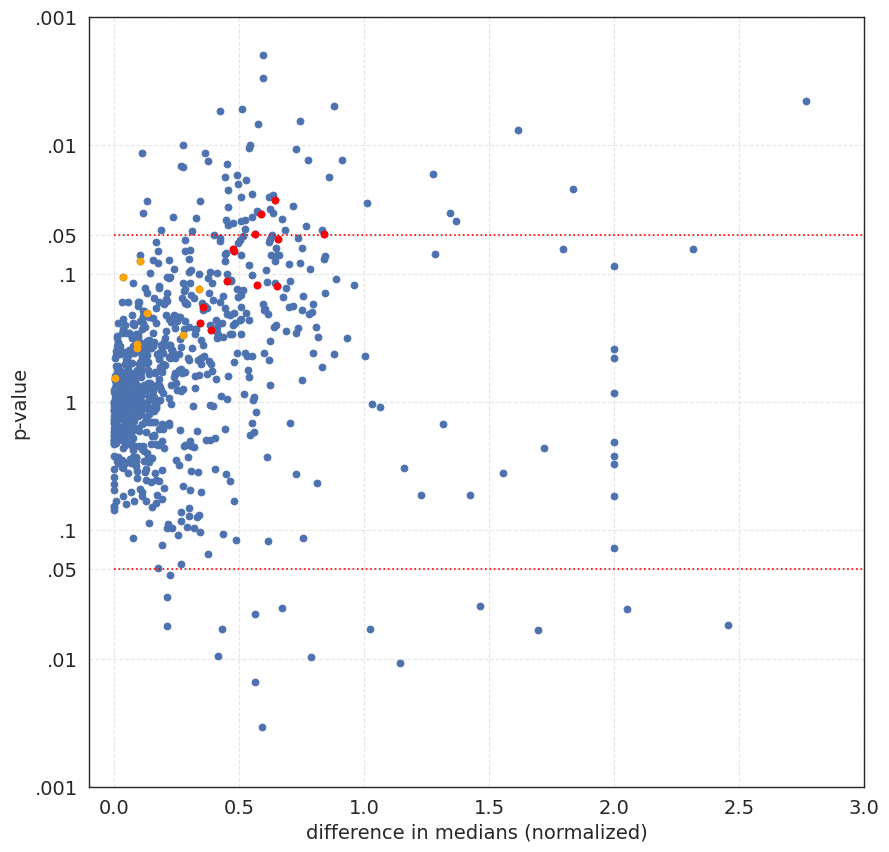

In [100]:
# Fig 2g - association of response with various transcriptomic features, highlighting mhc1 and mhc2 genes
# Plot neglogpval on y axis, difference in medians on the x axis
import warnings
warnings.filterwarnings("ignore")
def PlotPValDiffs(df, ax = None, colorGenes = None, labelGenes = None):
    if ax == None:
        ax = plt.subplot()
      
    graphDF = df.copy()
    graphDF['neg log pval'] = [-math.log(x, 10) for x in df['pval']]
    responder = []
    signedMedDiff = []
    for x in df['median diffs']:
        if x > 0:
            responder += [1]
        else:
            responder += [-1]
        signedMedDiff += [abs(x)]
    graphDF['neg log pval'] = graphDF['neg log pval'] * responder
    graphDF['median diffs'] = signedMedDiff
    ax.scatter(graphDF['median diffs'], graphDF['neg log pval'])
    if colorGenes is not None:
        for color in colorGenes:
            ax.scatter(graphDF.loc[colorGenes[color], 'median diffs'], 
                       graphDF.loc[colorGenes[color], 'neg log pval'], 
                       color=color)

    ax.set_ylabel('p-value')
    ax.set_xlabel('difference in medians')
    
    sigY = -math.log(0.05,10)

    ax.set_yticks([-3,-2, -sigY, -1,0,1, sigY, 2,3])
    ax.set_yticklabels(['.001','.01', '.05', '.1','1','.1','.05','.01','.001'])
    
    # create red dotted line for significance
    sigY = -math.log(0.05,10)
    ax.plot([0,10],[sigY, sigY], color='red', linestyle=":")
    ax.plot([0,10],[-sigY, -sigY], color='red', linestyle=":")
    
    # label Points
    if labelGenes is not None:
        x = graphDF.loc[labelGenes,'median diffs']
        y = graphDF.loc[labelGenes,'neg log pval']
        for i in range(0,len(labelGenes)):
            x_offset = 3
            y_offset = 0.1
            ax.text(x[i] + x_offset,y[i] + y_offset, labelGenes[i])
            ax.plot([x[i], x[i] + x_offset],[y[i], y[i] + y_offset], color='black' )
    return ax
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5']

graphDF = degs_df[['Pvalue', 'DiffMedian']]

graphDF.columns = ['pval', 'median diffs']
fig = plt.figure(figsize=(10,10))
ax = plt.subplot()

colorGenes = {'red':mhc2,
             'orange':mhc1}

PlotPValDiffs(graphDF, ax = ax, colorGenes = colorGenes, labelGenes = None)
ax.set_xlim(-0.1,3)
ax.set_ylim(-3,3)
ax.set_xlabel('difference in medians (normalized)')

0

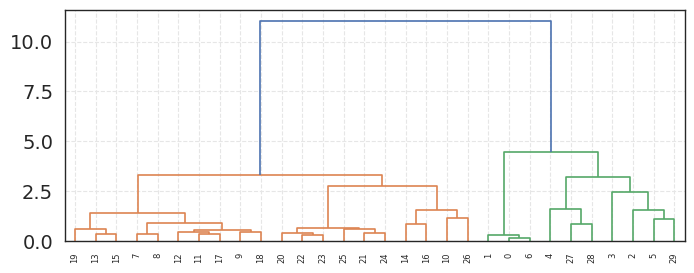

<Figure size 1200x1200 with 0 Axes>

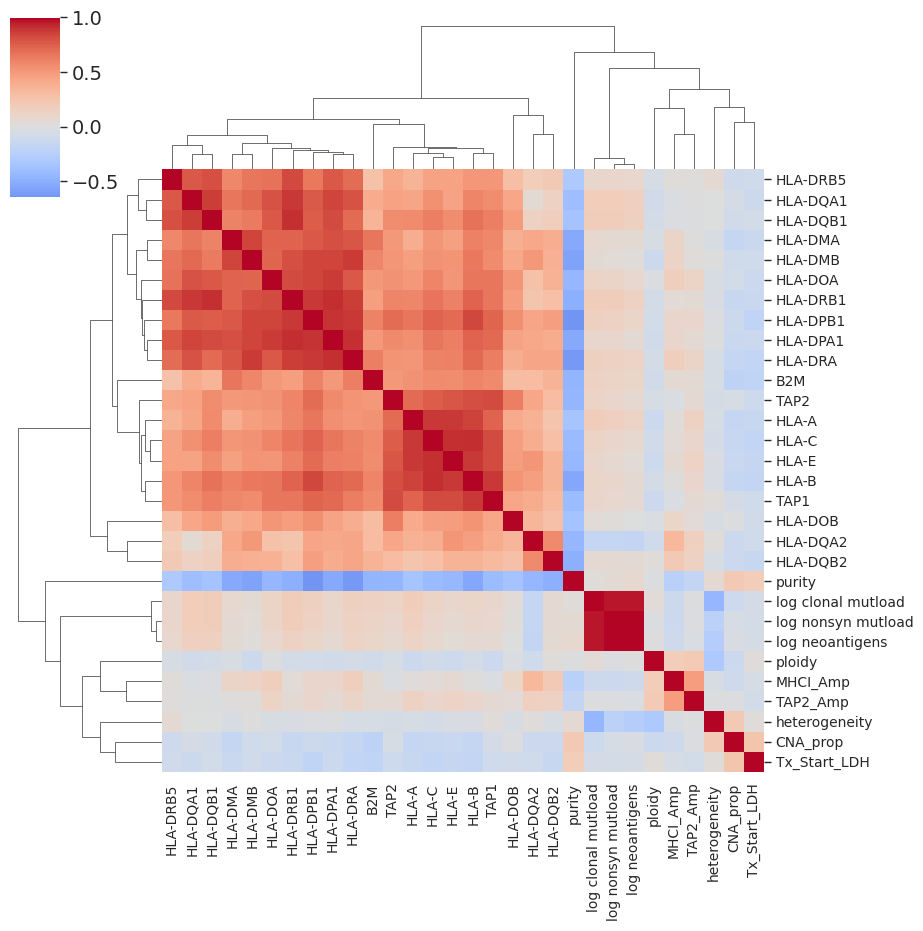

In [114]:
# Fig 2h - hierarchical clustering of genomic and transcriptomic features
from scipy.cluster.hierarchy import dendrogram, linkage

comparators = [
            'log nonsyn mutload',
             'log clonal mutload',
              'heterogeneity',
              'purity',
                'ploidy',
             'CNA_prop',
               'log neoantigens',
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5',
            'HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'TAP1', 'TAP2', 'B2M',
            'MHCI_Amp',
            'TAP2_Amp',
               'Tx_Start_LDH',
                ]

# Generate the co-correlation matrix and hierarchical clustering based on heat map

features = comparators

# generate the correlations for features in tumorDF first
tumorDFFeatures = [x for x in features if x in fullDF.columns]

tumorDFCorr = pd.DataFrame(columns = tumorDFFeatures)
for feature in tumorDFFeatures:
    tumorDFCorr[feature] = pd.to_numeric(fullDF[feature], errors="coerce") # coerce to numerics
    
tumorDFcorrmat = tumorDFCorr.corr()

corrDF = pd.DataFrame(columns = features)
for feature in features:
    corrDF[feature] = pd.to_numeric(fullDF[feature], errors="coerce") # coerce to numerics
corrmat = corrDF.corr() 

for feature in tumorDFFeatures: # replace entries where they exist
    for feature2 in tumorDFFeatures:
        corrmat.loc[feature, feature2] = tumorDFcorrmat.loc[feature, feature2]

#corrmat = batch1fullDF.ix[cbTest+ncbTest, numericFeatures].corr()
Z = linkage(corrmat, 'ward') # generate the linkage/hierarchical clustering
order = [int(s) for s in dendrogram(Z, leaf_rotation=90, leaf_font_size=6)['ivl']]

# Generate the heatmap
plt.figure(figsize = (12,12))
# ax = plt.subplot()
# sns.heatmap(corrmat.index[order, order], vmax = 1, vmin = -1, square = True, cmap = "RdBu", fontsize=10)
cg = sns.clustermap(corrmat.iloc[order,order], cmap="coolwarm", center=0, 
                    yticklabels=True, xticklabels=True)
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=10)
plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), fontsize=10)
0

In [36]:
# generate response groups stratified by prior ipilimumab treatment status
# Generate a category for allRNADF to compare nonresponders (ipi-experienced) vs nonresponders (ipi-naive)
ipiTreated = list(fullDF[fullDF["IpiTreated"]==1].index)
postIpi = list(fullDF[fullDF["PostIpi"]==1].index)
preIpi = list(fullDF[fullDF["PreIpi"]==1].index)
noIpi = list(fullDF[fullDF["IpiTreated"]==0].index)

print("Total pre-ipi patients:", len(preIpi))
print("Total post-ipi patients:", len(postIpi))
print("Total ipi-naive patients:", len(noIpi))

PDpostIpi = list(set(postIpi).intersection(set(progressors)))
PDnoIpi = list(set(noIpi).intersection(set(progressors)))
RpostIpi = list(set(postIpi).intersection(set(responders)))
RnoIpi = list(set(noIpi).intersection(set(responders)))
nPDpostIpi = [x for x in postIpi if x not in progressors] 
nPDnoIpi = [x for x in noIpi if x not in progressors] 

Total pre-ipi patients: 12
Total post-ipi patients: 34
Total ipi-naive patients: 75


In [116]:
from scipy.stats import mannwhitneyu
fullDF_ssGSEA = pd.concat([fullDF,res_wide["MHC-II"]], axis = 1)

#Overall:
# overallIP_df = fullDF_ssGSEA[fullDF_ssGSEA["IpiTreated"]==1]
responders_df = fullDF_ssGSEA[fullDF_ssGSEA["PD vs Responder"]=="Responder"]
progressor_df = fullDF_ssGSEA[fullDF_ssGSEA["PD vs Responder"]=="Progressor"]

mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Overall---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "greater")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

#PostIP:
postIP_df = fullDF_ssGSEA[fullDF_ssGSEA["PostIpi"]==1]
responders_df = postIP_df[postIP_df["PD vs Responder"]=="Responder"]
progressor_df = postIP_df[postIP_df["PD vs Responder"]=="Progressor"]
mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Ipi-Experience---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "greater")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

#IpiNaive
naiveIP_df = fullDF_ssGSEA[fullDF_ssGSEA["IpiTreated"]==0]
responders_df = naiveIP_df[naiveIP_df["PD vs Responder"]=="Responder"]
progressor_df = naiveIP_df[naiveIP_df["PD vs Responder"]=="Progressor"]

mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Ipi-Naive---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "greater")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

---Overall---
47 Responders: Mean 5426.994459770369
56 Progressor:  Mean 4648.099933299047
 P-value: 0.01506357934715396
---Ipi-Experience---
11 Responders: Mean 6370.3007551626715
16 Progressor:  Mean 5263.000854753703
 P-value: 0.025636853074524065
---Ipi-Naive---
31 Responders: Mean 5099.655703954848
34 Progressor:  Mean 4564.216298207248
 P-value: 0.10727206399818945


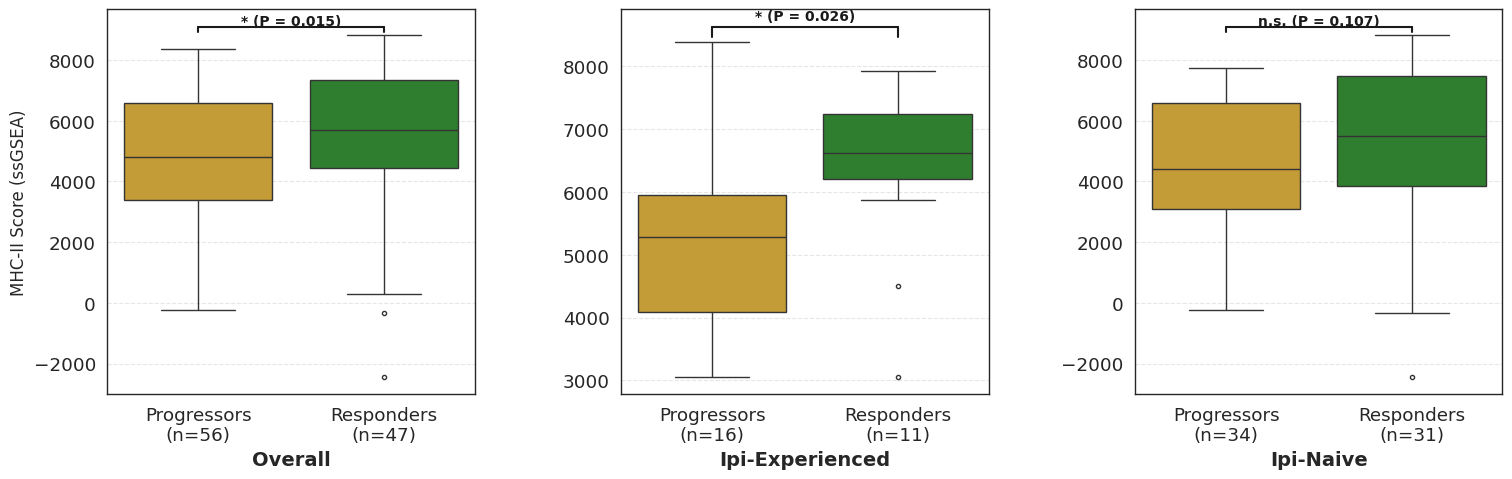

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu

RESPONDER_COL = "forestgreen"
NRESPONDER_COL = "goldenrod"

sig = 'MHC-II' # Tên cột chữ ký
outcomes = ['RvsPD', 'RvsPD-ipi-exp', 'RvsPD-ipi-naive']

# Định nghĩa lại thông tin so sánh theo cấu trúc dữ liệu của bạn
plot_specs = {
    'RvsPD': {
        'df': fullDF_ssGSEA,
        'title_suffix': 'Overall',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    },
    'RvsPD-ipi-exp': {
        'df': fullDF_ssGSEA[fullDF_ssGSEA["PostIpi"] == 1], 
        'title_suffix': 'Ipi-Experienced',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    },
    'RvsPD-ipi-naive': {
        'df': fullDF_ssGSEA[fullDF_ssGSEA["IpiTreated"] == 0], 
        'title_suffix': 'Ipi-Naive',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    }
}

# HÀM ĐIỀU CHỈNH: Format P-value và vị trí thanh ngang
def format_pvalue_and_line(ax, pvalue, y_max_data):
    stars = ""
    if pvalue < 0.001:
        stars = "***"
    elif pvalue < 0.01:
        stars = "**"
    elif pvalue < 0.05:
        stars = "*"
    
    # Cú pháp P-value mới (một dòng)
    if pvalue < 0.001:
        text = f"{stars} (P < 0.001)"
    elif pvalue < 0.05:
        text = f"{stars} (P = {pvalue:.3f})"
    else:
        text = f"n.s. (P = {pvalue:.3f})"
        
    # Điều chỉnh vị trí thanh ngang (y_line) và chữ (y_text)
    # Giảm offset từ 10% xuống 5% để hạ thanh bar
    offset_from_max = y_max_data * 0.03
    text_spacing = y_max_data * 0.02  
    
    y_line = y_max_data + offset_from_max 
    y_text = y_line + text_spacing
    
    x1, x2 = 0, 1 # Vị trí boxplot
    
    # 3a. Vẽ thanh dọc (chân thanh ngang)
    bar_height = y_max_data * 0.02
    ax.plot([x1, x1], [y_line, y_line - bar_height], lw=1.5, c='k') 
    ax.plot([x2, x2], [y_line, y_line - bar_height], lw=1.5, c='k') 

    # 3b. Vẽ thanh ngang nối 
    ax.plot([x1, x2], [y_line, y_line], lw=1.5, c='k')

    # 3c. Vẽ chữ P-value
    ax.text((x1 + x2) / 2, y_text, text, 
            ha='center', 
            va='center', 
            fontsize=10, 
            color='k', 
            fontweight='bold')
            
    return y_text * 1.05 

ncols = len(outcomes)
nrows = 1
gs = gridspec.GridSpec(nrows, ncols, wspace=0.4, hspace = 0.4)

fig = plt.figure(figsize=(6*ncols, 5))
sns.set_context("paper", font_scale=1.5) 

i = 0
y_lim_max = 0 

for outcome in outcomes:
    ax = plt.subplot(gs[i])
    spec = plot_specs[outcome]
    
    current_df = spec['df']
    group1_df = current_df[current_df[spec['group_col']] == spec['group1_val']]
    group2_df = current_df[current_df[spec['group_col']] == spec['group2_val']]

    # 1. TÍNH TOÁN P-VALUE và N
    mhcii_score_g1 = group1_df[sig].values.tolist()
    mhcii_score_g2 = group2_df[sig].values.tolist()
    
    if len(mhcii_score_g1) > 0 and len(mhcii_score_g2) > 0:
        _, pvalue = mannwhitneyu(mhcii_score_g2, mhcii_score_g1, alternative = "greater")
    else:
        pvalue = np.nan
    
    n1 = len(mhcii_score_g1)
    n2 = len(mhcii_score_g2)
    
    # 2. CHUẨN BỊ DATAFRAME VẼ (graphDF)
    group1label = spec['label1'] + '\n(n=' + str(n1) + ')'
    group2label = spec['label2'] + '\n(n=' + str(n2) + ')'
    
    plot_df = pd.DataFrame({
        sig: group1_df[sig].tolist() + group2_df[sig].tolist(),
        'GroupLabel': [group1label] * n1 + [group2label] * n2
    })
    
    # 3. VẼ BOXPLOT
    sns.boxplot(x = 'GroupLabel', y = sig, data=plot_df, 
                order=[group1label, group2label],
                palette = [NRESPONDER_COL, RESPONDER_COL],
                fliersize=3,
                ax=ax)
    
    # 4. VẼ THANH P-VALUE VÀ CHÚ THÍCH (Sử dụng hàm đã điều chỉnh)
    if not np.isnan(pvalue):
        max_y_current = plot_df[sig].max() 
        y_max_annotated = format_pvalue_and_line(ax, pvalue, max_y_current)
        y_lim_max = max(y_lim_max, y_max_annotated)
    
    # 5. ĐỊNH DẠNG TRỤC
    ax.set_xlabel(spec['title_suffix'], fontsize=14, fontweight='bold')
    
    if i == 0:
        ax.set_ylabel(f'{sig} Score (ssGSEA)', fontsize=12)
    else:
        ax.set_ylabel('')

    plt.xticks(rotation=0)
    
    i += 1

# Áp dụng giới hạn Y tối đa chung cho tất cả các subplots
for ax in axes:
    min_y_data = fullDF_ssGSEA[sig].min()
    y_min_plot = min_y_data * 0.9 if min_y_data > 0 else min_y_data * 1.1 # Đảm bảo min_y_plot không quá gần 0 nếu data > 0
    ax.set_ylim(y_min_plot, y_lim_max) 

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [18]:
import gseapy as gp
overall_df = fullDF[~fullDF["PD vs Responder"].isna()]
cohort = list(overall_df.index)
allRNADF_T = allRNADF.T.reset_index()
allRNADF_T.columns.values[0] = 'Gene'
allRNADF_overall = pd.concat([allRNADF_T["Gene"], allRNADF_T[cohort]], axis = 1)


phenoA = "Responder"
phenoB = "Progressor"
class_vectors = overall_df["PD vs Responder"].values
gs_res = gp.gsea(data=allRNADF_overall, # or data='./P53_resampling_data.txt'
                 gene_sets=gmt_dict, # or enrichr library names
                 cls= class_vectors, # cls=class_vector
                 # set permutation_type to phenotype if samples >=15
                 organism='human',
                 permutation_type='phenotype',
                 permutation_num=10000, # reduce number to speed up test
                 outdir=None,  # do not write output to disk
                 method='signal_to_noise',
                 threads=24, seed= 42, verbose = True)

gs_res.pheno_pos = phenoA
gs_res.pheno_neg = phenoB
gs_res.run()

2025-11-12 00:15:42,621 [INFO] Parsing data files for GSEA.............................
2025-11-12 00:15:42,751 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-12 00:15:42,752 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-12 00:15:42,753 [INFO] Start to run GSEA...Might take a while..................
2025-11-12 00:17:11,510 [INFO] Congratulations. GSEApy ran successfully.................



In [23]:
result_df = gs_res.res2d
result_df[result_df["Term"]=='HALLMARK_INTERFERON_GAMMA_RESPONSE']

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
6,gsea,HALLMARK_INTERFERON_GAMMA_RESPONSE,0.453792,1.41565,0.183138,0.605102,0.5854,100/194,29.38%,IRF8;SLAMF7;PTPN6;CSF2RB;PFKP;IL10RA;ITGB7;HLA...


In [26]:
result_df.sort_values(by="FDR q-val")

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,HALLMARK_ALLOGRAFT_REJECTION,0.576062,1.861806,0.020646,0.24656,0.0876,93/190,15.88%,IRF8;MMP9;LCK;CD28;ITGB2;CD79A;PTPN6;PRKCB;WAS...
1,gsea,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,0.489197,1.682436,0.026547,0.486016,0.2527,18/49,21.62%,IPCEF1;PFKP;LSP1;MPO;JUNB;FTL;HMOX2;OXSR1;SELE...
2,gsea,HALLMARK_HEME_METABOLISM,0.362637,1.593952,0.016707,0.566782,0.3633,68/189,24.69%,ACP5;AHSP;CLIC2;DCAF11;BLVRA;FECH;MAP2K3;SLC30...
4,gsea,HALLMARK_IL6_JAK_STAT3_SIGNALING,0.467851,1.500287,0.112008,0.567561,0.4882,51/86,30.19%,CSF2RB;IL2RG;LTB;TNFRSF1B;PIK3R5;CD9;GRB2;CSF1...
6,gsea,HALLMARK_INTERFERON_GAMMA_RESPONSE,0.453792,1.41565,0.183138,0.605102,0.5854,100/194,29.38%,IRF8;SLAMF7;PTPN6;CSF2RB;PFKP;IL10RA;ITGB7;HLA...
7,gsea,HALLMARK_INFLAMMATORY_RESPONSE,0.392588,1.378233,0.168455,0.623246,0.6314,84/197,25.49%,LCK;SELL;TNFRSF9;IL10RA;PTGER4;P2RX4;CD48;TNFR...
8,gsea,HALLMARK_MYC_TARGETS_V2,0.454058,1.341684,0.206044,0.644444,0.6706,36/57,37.83%,NOP2;DUSP2;UNG;RRP12;RCL1;PPAN;NOC4L;AIMP2;MRT...
9,gsea,HALLMARK_APOPTOSIS,0.322389,1.312354,0.159853,0.651142,0.7,72/159,30.98%,CD2;BTG2;PRF1;DFFA;RETSAT;PLCB2;BIRC3;FASLG;LG...
5,gsea,HALLMARK_COMPLEMENT,0.378875,1.433346,0.100594,0.6516,0.5647,72/195,24.24%,LCK;PLEK;WAS;LGMN;PLA2G7;GZMA;STX4;CTSS;CTSH;S...
10,gsea,HALLMARK_IL2_STAT5_SIGNALING,0.321725,1.281212,0.177043,0.665806,0.731,79/196,28.18%,IRF8;SELL;NOP2;TNFRSF9;PRKCH;IL10RA;ICOS;CAPG;...
